# Predicción de la velocidad de adopción de gatos mediante Machine Learning

**Curso:** Ingeniería del Conocimiento  
**Estudiante:** Alejandro

## Objetivo

Aplicar el ciclo de vida de un proyecto de Machine Learning para analizar y predecir la velocidad de adopción de gatos a partir de sus características físicas, condiciones de salud y características del anuncio de adopción.

El conjunto de datos utilizado corresponde a PetFinder.my Adoption Prediction. Para este trabajo se utilizaron únicamente los registros correspondientes a gatos.

## 1. Configuración del entorno

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Entorno configurado correctamente.")

Entorno configurado correctamente.


## 2. Carga y selección de datos

In [13]:
df = pd.read_csv("train.csv")

print(f"Dataset cargado: {df.shape[0]} registros y {df.shape[1]} columnas")
df.head()

Dataset cargado: 14993 registros y 24 columnas


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,...,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,...,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,...,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


## 3. Exploración y preparación de los datos

In [14]:
df_gatos = df[df['Type'] == 2].copy()

print(f"Registros totales: {df.shape[0]}")
print(f"Gatos encontrados: {df_gatos.shape[0]}")
print(f"Columnas: {df_gatos.shape[1]}")

Registros totales: 14993
Gatos encontrados: 6861
Columnas: 24


In [15]:
print("=" * 50)
print("INFORMACIÓN DEL DATASET DE GATOS")
print("=" * 50)

df_gatos.info()

print("\nValores nulos por columna:")
print(df_gatos.isnull().sum())

print(f"\nRegistros duplicados: {df_gatos.duplicated().sum()}")

print("\nDistribución de AdoptionSpeed:")
print(df_gatos['AdoptionSpeed'].value_counts().sort_index())

INFORMACIÓN DEL DATASET DE GATOS
<class 'pandas.core.frame.DataFrame'>
Index: 6861 entries, 0 to 14991
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Type           6861 non-null   int64  
 1   Name           6249 non-null   object 
 2   Age            6861 non-null   int64  
 3   Breed1         6861 non-null   int64  
 4   Breed2         6861 non-null   int64  
 5   Gender         6861 non-null   int64  
 6   Color1         6861 non-null   int64  
 7   Color2         6861 non-null   int64  
 8   Color3         6861 non-null   int64  
 9   MaturitySize   6861 non-null   int64  
 10  FurLength      6861 non-null   int64  
 11  Vaccinated     6861 non-null   int64  
 12  Dewormed       6861 non-null   int64  
 13  Sterilized     6861 non-null   int64  
 14  Health         6861 non-null   int64  
 15  Quantity       6861 non-null   int64  
 16  Fee            6861 non-null   int64  
 17  State          6861 non

In [16]:
columnas_eliminar = [
    'Type',
    'Name',
    'RescuerID',
    'Description',
    'PetID'
]

df_modelo = df_gatos.drop(columns=columnas_eliminar).copy()

print(f"Dataset preparado: {df_modelo.shape[0]} registros y {df_modelo.shape[1]} columnas")
print("\nColumnas disponibles:")
print(df_modelo.columns.tolist())

print(f"\nValores nulos totales: {df_modelo.isnull().sum().sum()}")

Dataset preparado: 6861 registros y 19 columnas

Columnas disponibles:
['Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'Quantity', 'Fee', 'State', 'VideoAmt', 'PhotoAmt', 'AdoptionSpeed']

Valores nulos totales: 0


## 4. Preparación para el modelado

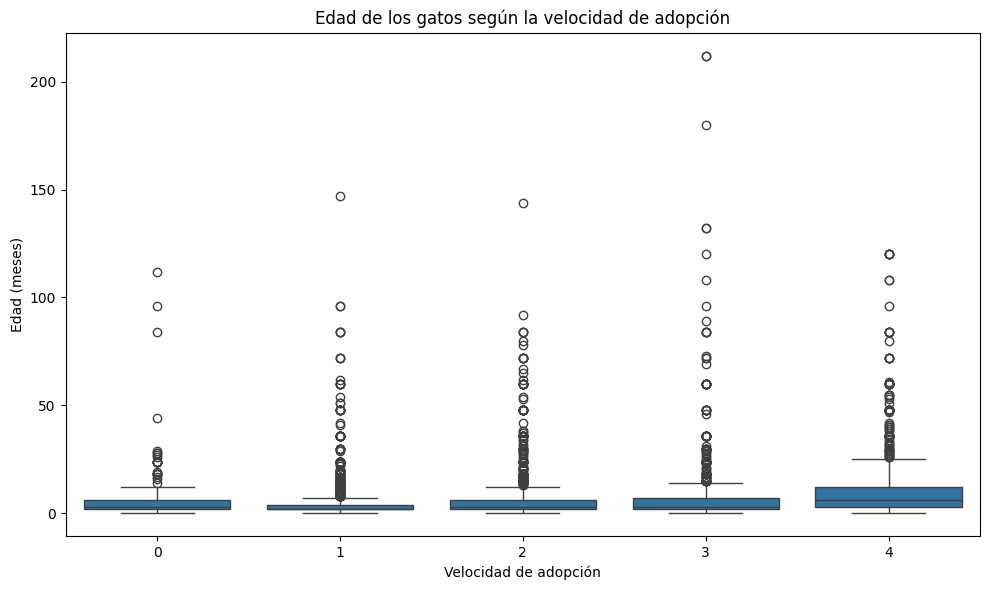

In [17]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_gatos,
    x='AdoptionSpeed',
    y='Age'
)

plt.title('Edad de los gatos según la velocidad de adopción')
plt.xlabel('Velocidad de adopción')
plt.ylabel('Edad (meses)')

plt.tight_layout()
plt.show()

In [18]:
tabla_esterilizacion = pd.crosstab(
    df_gatos['Sterilized'],
    df_gatos['AdoptionSpeed'],
    normalize='index'
) * 100

tabla_esterilizacion.round(2)

AdoptionSpeed,0,1,2,3,4
Sterilized,,,,,
1,2.78,13.43,22.42,19.87,41.49
2,3.40,27.09,29.56,19.63,20.31
3,5.44,22.49,20.20,13.90,37.97


In [19]:
features = [
    'Age',
    'Breed1',
    'Breed2',
    'Gender',
    'Color1',
    'Color2',
    'Color3',
    'MaturitySize',
    'FurLength',
    'Vaccinated',
    'Dewormed',
    'Sterilized',
    'Health',
    'Quantity',
    'Fee',
    'State',
    'VideoAmt',
    'PhotoAmt'
]

X = df_modelo[features]
y = df_modelo['AdoptionSpeed']

print(f"Características (X): {X.shape}")
print(f"Objetivo (y): {y.shape}")

Características (X): (6861, 18)
Objetivo (y): (6861,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Datos de entrenamiento: {X_train.shape[0]}")
print(f"Datos de prueba: {X_test.shape[0]}")

Datos de entrenamiento: 5488
Datos de prueba: 1373


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = [
    'Age',
    'Quantity',
    'Fee',
    'VideoAmt',
    'PhotoAmt'
]

categorical_features = [
    'Breed1',
    'Breed2',
    'Gender',
    'Color1',
    'Color2',
    'Color3',
    'MaturitySize',
    'FurLength',
    'Vaccinated',
    'Dewormed',
    'Sterilized',
    'Health',
    'State'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print("Preprocesamiento configurado correctamente.")

Preprocesamiento configurado correctamente.


## 5. Entrenamiento y comparación de modelos

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

modelos = {
    'Regresión Logística': LogisticRegression(
        max_iter=2000,
        class_weight='balanced'
    ),
    'Árbol de Decisión': DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )
}

resultados = {}

for nombre, modelo in modelos.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('modelo', modelo)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    resultados[nombre] = scores.mean()

    print(f"{nombre}: {scores.mean():.4f}")

Regresión Logística: 0.2966
Árbol de Decisión: 0.3096
Random Forest: 0.3608


## 6. Evaluación del modelo

In [23]:
from sklearn.metrics import accuracy_score, classification_report

modelo_final = Pipeline([
    ('preprocessor', preprocessor),
    ('modelo', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

modelo_final.fit(X_train, y_train)

y_pred = modelo_final.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy en prueba: {accuracy:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Accuracy en prueba: 0.3634

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.31      0.08      0.13        48
           1       0.33      0.37      0.35       331
           2       0.33      0.36      0.34       375
           3       0.28      0.14      0.19       262
           4       0.45      0.56      0.50       357

    accuracy                           0.36      1373
   macro avg       0.34      0.30      0.30      1373
weighted avg       0.35      0.36      0.35      1373



In [24]:
import joblib

joblib.dump(modelo_final, "modelo_adopcion_gatos.pkl")

print("Modelo guardado correctamente como 'modelo_adopcion_gatos.pkl'")

Modelo guardado correctamente como 'modelo_adopcion_gatos.pkl'


## 8. Conclusiones

Se evaluaron tres algoritmos de clasificación: Regresión Logística, Árbol de Decisión y Random Forest. Mediante validación cruzada, Random Forest obtuvo el mejor rendimiento, con una exactitud promedio de 36.08%.

Al evaluar el modelo seleccionado sobre el conjunto de prueba, se obtuvo una exactitud de 36.34%. El modelo presentó su mejor desempeño en la categoría 4 de velocidad de adopción, mientras que tuvo mayores dificultades para reconocer la categoría 0, que cuenta con una cantidad considerablemente menor de registros.

Los resultados indican que las características disponibles contienen información útil para la predicción de la velocidad de adopción, aunque no permiten realizar una clasificación altamente precisa. Variables adicionales, como información extraída de las imágenes o del texto de las publicaciones, podrían aportar información adicional para mejorar el modelo.